e:\Python\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
e:\Python\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


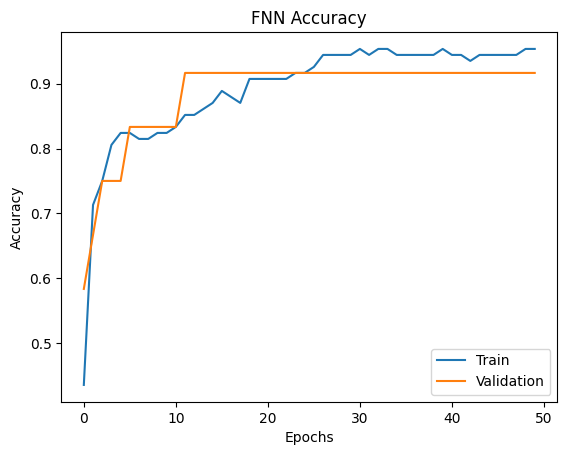

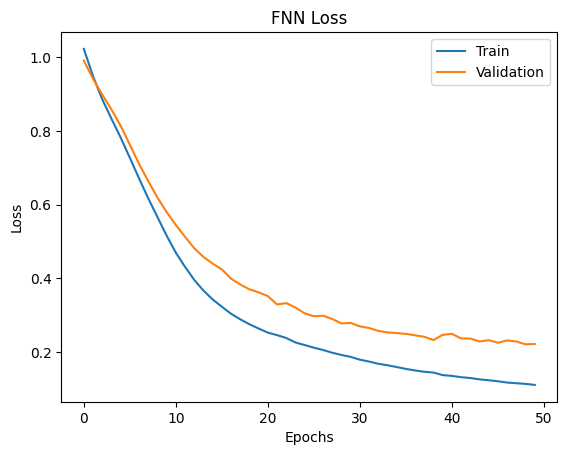

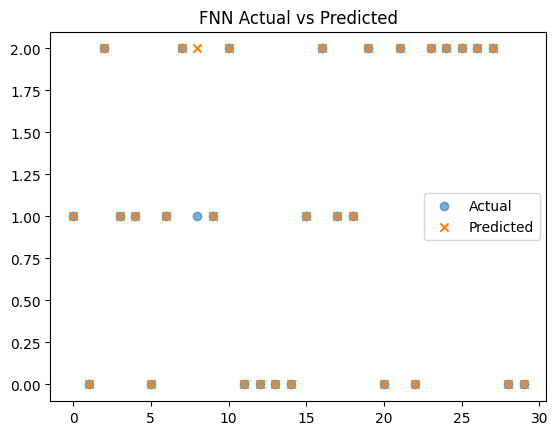

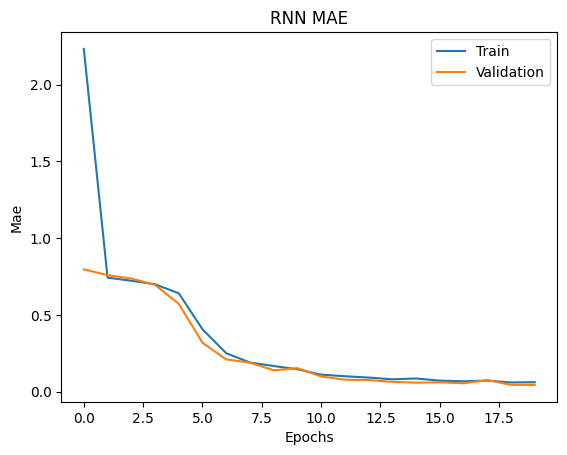

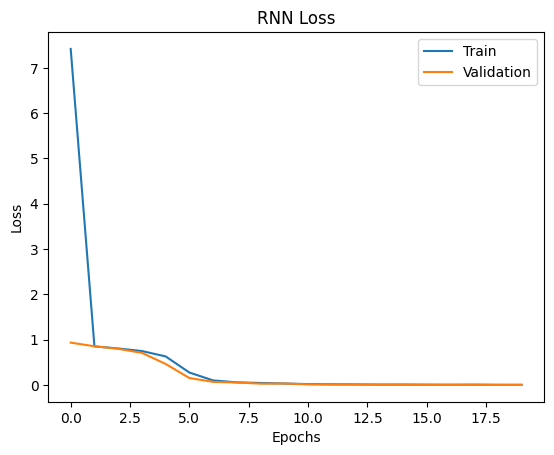

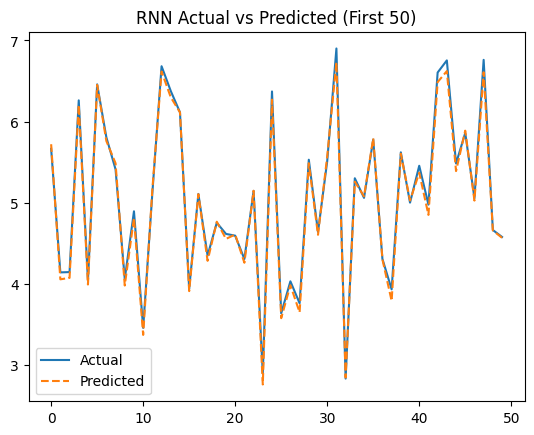

FNN Accuracy: 0.9667
RNN MAE: 0.0533
FNN Predictions (First 10): [1 0 2 1 1 0 1 2 2 1]
RNN Predictions (First 5):
 [[5.7208767]
 [4.056896 ]
 [4.074838 ]
 [6.205415 ]
 [3.9929314]]


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow import keras 
from tensorflow.keras import layers 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import load_iris 

# --- Helper Function to Simplify Plotting ---
def plot_history(history, metric, title, is_loss=False):
    plt.figure()
    plt.plot(history.history[metric], label='Train')
    plt.plot(history.history[f'val_{metric}'], label='Validation')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss' if is_loss else metric.capitalize())
    plt.legend()

# ==========================================
# PART 1: Feedforward Neural Network (FNN) - Iris Classification
# ==========================================
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 

fnn_model = keras.Sequential([ 
    layers.Dense(16, activation='relu', input_shape=(4,)), 
    layers.Dense(12, activation='relu'), 
    layers.Dense(3, activation='softmax') 
]) 

fnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) 
history_fnn = fnn_model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0) 

loss_fnn, acc_fnn = fnn_model.evaluate(X_test, y_test, verbose=0) 
pred_fnn = np.argmax(fnn_model.predict(X_test, verbose=0), axis=1) 

# Plot FNN Results
plot_history(history_fnn, 'accuracy', 'FNN Accuracy')
plot_history(history_fnn, 'loss', 'FNN Loss', is_loss=True)

plt.figure() 
plt.scatter(range(len(y_test)), y_test, label='Actual', alpha=0.6) 
plt.scatter(range(len(pred_fnn)), pred_fnn, label='Predicted', marker='x') 
plt.title('FNN Actual vs Predicted') 
plt.legend()

# ==========================================
# PART 2: Recurrent Neural Network (RNN) - Sequence Summation
# ==========================================
X_seq = np.random.rand(1000, 10, 1) 
y_seq = np.sum(X_seq, axis=1) 
X_train_seq, X_test_seq = X_seq[:800], X_seq[800:] 
y_train_seq, y_test_seq = y_seq[:800], y_seq[800:] 

rnn_model = keras.Sequential([ 
    layers.SimpleRNN(32, activation='tanh', input_shape=(10, 1)), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(1) 
]) 

rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) 
history_rnn = rnn_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=16, validation_split=0.1, verbose=0) 

loss_rnn, mae_rnn = rnn_model.evaluate(X_test_seq, y_test_seq, verbose=0) 
pred_rnn = rnn_model.predict(X_test_seq, verbose=0) 

# Plot RNN Results
plot_history(history_rnn, 'mae', 'RNN MAE')
plot_history(history_rnn, 'loss', 'RNN Loss', is_loss=True)

plt.figure() 
plt.plot(y_test_seq[:50], label='Actual') 
plt.plot(pred_rnn[:50], label='Predicted', linestyle='--') 
plt.title('RNN Actual vs Predicted (First 50)') 
plt.legend()

# ==========================================
# PART 3: Final Outputs
# ==========================================
plt.show() 

print(f"FNN Accuracy: {acc_fnn:.4f}") 
print(f"RNN MAE: {mae_rnn:.4f}") 
print("FNN Predictions (First 10):", pred_fnn[:10]) 
print("RNN Predictions (First 5):\n", pred_rnn[:5])